# Atelier ML — Analyse Comportementale Clientèle Retail
### Version corrigée — sans data leakage

## Étape 0 — Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight

for folder in ['../models', '../reports', '../data/processed', '../data/train_test']:
    os.makedirs(folder, exist_ok=True)

print('Imports OK')

Imports OK


## Étape 1 — Chargement et exploration (EDA)

In [2]:
df_raw = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
print(f'Shape : {df_raw.shape}')
print(f'Colonnes : {list(df_raw.columns)}')
df_raw.head(3)

Shape : (4372, 52)
Colonnes : ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Churn']


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0


Distribution Churn :
Churn
0    2918
1    1454
Name: count, dtype: int64
Taux de churn : 33.3%


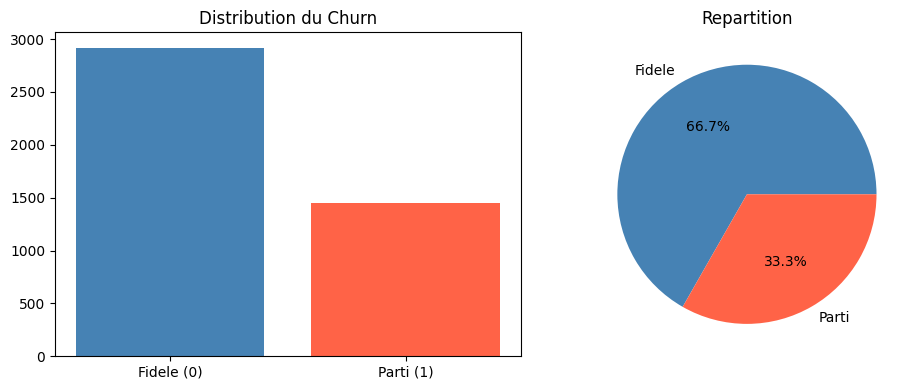

In [3]:
# Distribution de la target
print('Distribution Churn :')
print(df_raw['Churn'].value_counts())
print(f'Taux de churn : {df_raw["Churn"].mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df_raw['Churn'].value_counts()
axes[0].bar(['Fidele (0)', 'Parti (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribution du Churn')
axes[1].pie(counts.values, labels=['Fidele', 'Parti'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'])
axes[1].set_title('Repartition')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png')
plt.show()

In [4]:
# Valeurs manquantes
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Valeurs manquantes :')
print(missing)

# Valeurs aberrantes connues
print('\nSupportTicketsCount uniques :', sorted(df_raw['SupportTicketsCount'].dropna().unique()))
print('SatisfactionScore uniques   :', sorted(df_raw['SatisfactionScore'].dropna().unique()))

Valeurs manquantes :
Age                        1311
AvgDaysBetweenPurchases      79
dtype: int64

SupportTicketsCount uniques : [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(999.0)]
SatisfactionScore uniques   : [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0)]


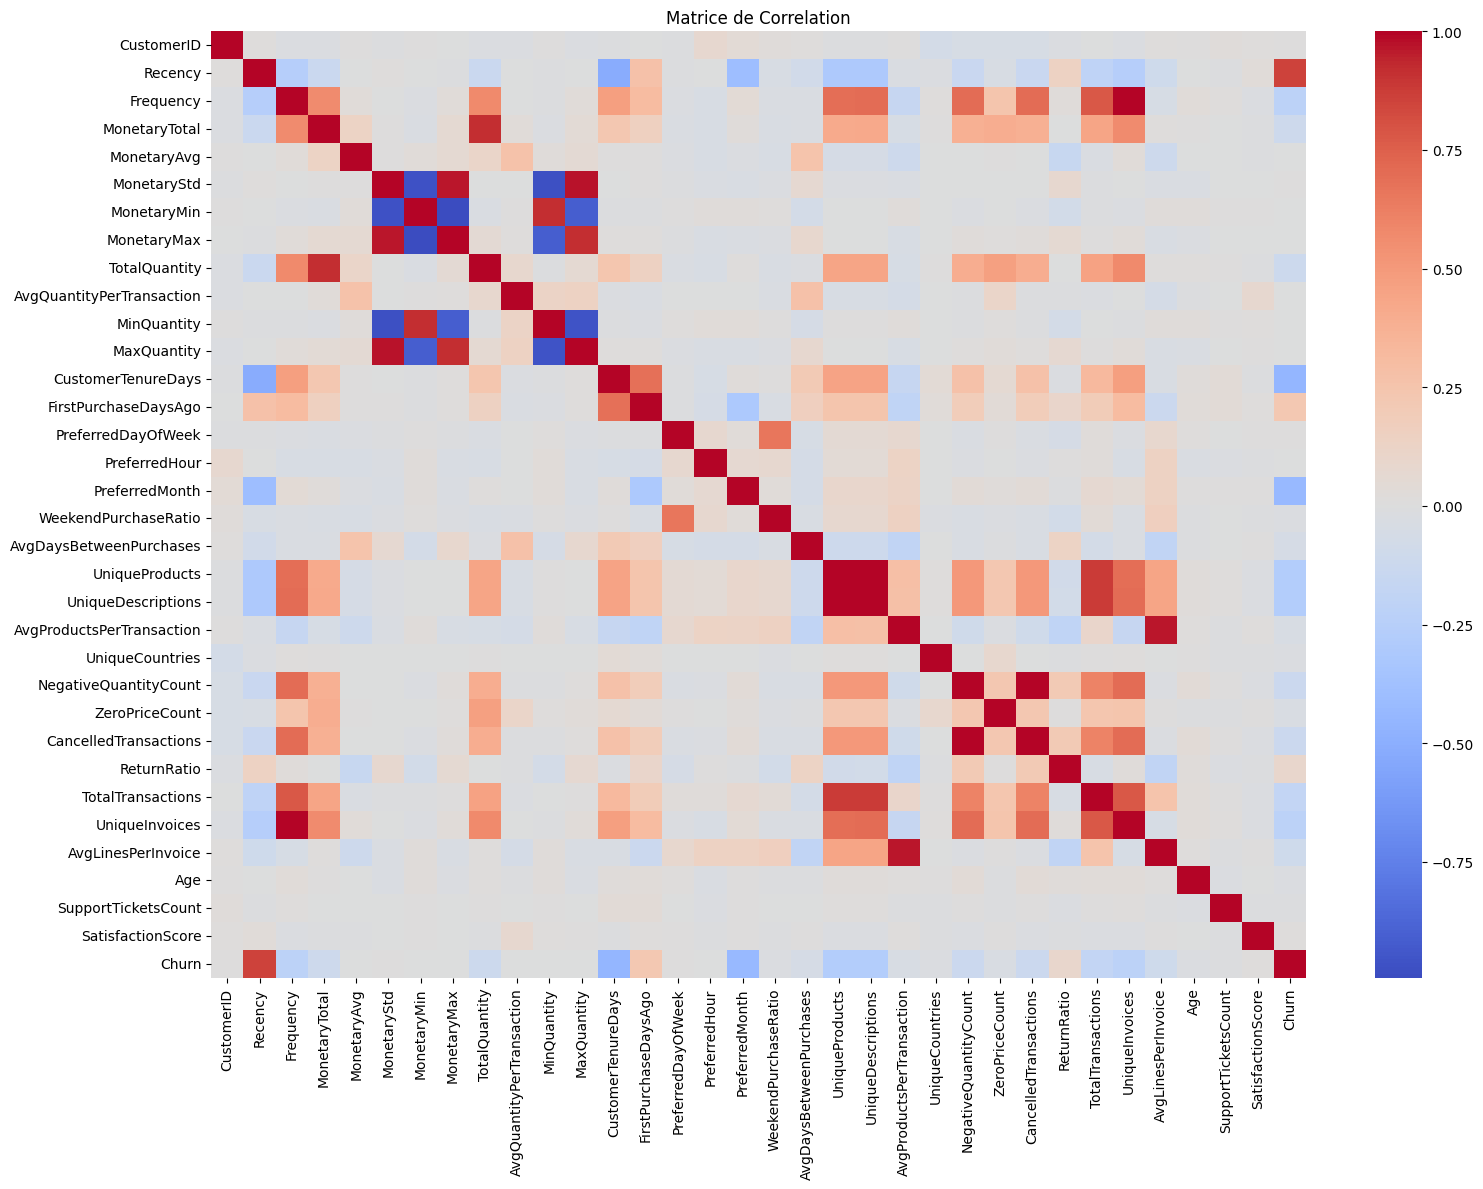

In [5]:
# Heatmap de correlation (features numeriques)
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, annot=False)
ax.set_title('Matrice de Correlation')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

## Étape 2 — Prétraitement
### IMPORTANT : colonnes supprimées pour éviter le data leakage
Les colonnes suivantes sont des **proxies directs** du Churn et doivent être retirées :
- `ChurnRiskCategory` : 100% corrélé avec Churn (Critique = toujours Churn=1)
- `CustomerType` : 'Perdu' = 100% Churn=1, 'Hyperactif/Regulier/Occasionnel' = 100% Churn=0
- `Recency` : séparation parfaite à 90 jours (Churn=0 si <90j, Churn=1 si >90j)
- `CustomerTenureDays`, `FirstPurchaseDaysAgo` : derivés de Recency
- `RFMSegment` : 'Dormants' = 100% Churn=1

In [6]:
df = df_raw.copy()

# ── 1. FEATURE ENGINEERING ──────────────────────────────────────
# Extraction depuis RegistrationDate
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], dayfirst=True, errors='coerce')
df['RegYear']    = df['RegistrationDate'].dt.year.fillna(2010).astype(int)
df['RegMonth']   = df['RegistrationDate'].dt.month.fillna(1).astype(int)
df['RegWeekday'] = df['RegistrationDate'].dt.weekday.fillna(0).astype(int)

# Extraction depuis LastLoginIP (IP privee ou non)
def ip_is_private(ip):
    try:
        parts = str(ip).split('.')
        if len(parts) != 4: return 0
        f, s = int(parts[0]), int(parts[1])
        return int(f==10 or (f==172 and 16<=s<=31) or (f==192 and s==168))
    except: return 0

df['IP_IsPrivate'] = df['LastLoginIP'].apply(ip_is_private)

# Nouvelles features utiles
df['MonetaryPerFreq']  = df['MonetaryTotal'] / (df['Frequency'] + 1)
df['TotalCancellRate'] = df['CancelledTransactions'] / (df['TotalTransactions'] + 1)

print('Feature engineering OK')

Feature engineering OK


In [7]:
# ── 2. SUPPRESSION DES COLONNES INUTILES ET PROXIES ─────────────
# Colonnes a supprimer ABSOLUMENT pour eviter accuracy=1
LEAK_COLS = [
    'Churn',               # la target (sera separee dans y)
    'ChurnRiskCategory',   # proxy parfait : Critique=Churn1, reste=Churn0
    'CustomerType',        # proxy parfait : Perdu=Churn1
    'RFMSegment',          # proxy fort  : Dormants=Churn1
    'Recency',             # separation parfaite a 90 jours
    'CustomerTenureDays',  # derive de Recency
    'FirstPurchaseDaysAgo',# derive de Recency
]

# Colonnes a supprimer (inutiles / variance nulle / identifiants)
DROP_COLS = [
    'CustomerID',
    'NewsletterSubscribed',  # variance nulle (toujours Yes)
    'LastLoginIP',           # remplace par IP_IsPrivate
    'RegistrationDate',      # remplace par RegYear/RegMonth/RegWeekday
]

all_to_drop = [c for c in LEAK_COLS + DROP_COLS if c in df.columns]
y = df['Churn'].copy()                    # sauvegarder la target
X = df.drop(columns=all_to_drop)          # tout sauf target et proxies

print(f'Colonnes supprimees : {all_to_drop}')
print(f'Shape X : {X.shape}')
print(f'Distribution y : {y.value_counts().to_dict()}')

Colonnes supprimees : ['Churn', 'ChurnRiskCategory', 'CustomerType', 'RFMSegment', 'Recency', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'CustomerID', 'NewsletterSubscribed', 'LastLoginIP', 'RegistrationDate']
Shape X : (4372, 47)
Distribution y : {0: 2918, 1: 1454}


In [8]:
# ── 3. NETTOYAGE DES VALEURS ABERRANTES ─────────────────────────
# SupportTicketsCount : -1 et 999 sont des codes erreur
X['SupportTicketsCount'] = X['SupportTicketsCount'].replace([-1, 999], np.nan)
# SatisfactionScore : -1, 0, 99 sont des codes erreur
X['SatisfactionScore'] = X['SatisfactionScore'].replace([-1, 0, 99], np.nan)
# MonetaryTotal : clip aux bornes du cahier des charges
X['MonetaryTotal'] = X['MonetaryTotal'].clip(-5000, 15000)
X['MonetaryMin']   = X['MonetaryMin'].clip(-5000, 5000)

print('Nettoyage OK')
print(f'NaN apres nettoyage : {X.isnull().sum()[X.isnull().sum()>0].to_dict()}')

Nettoyage OK
NaN apres nettoyage : {'AvgDaysBetweenPurchases': 79, 'Age': 1311, 'SupportTicketsCount': 130, 'SatisfactionScore': 349}


In [9]:
# ── 4. ENCODAGE DES VARIABLES CATEGORIELLES ─────────────────────

# Variables ordinales avec leur ordre
ORDINAL = {
    'AgeCategory':       ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Inconnu'],
    'SpendingCategory':  ['Low', 'Medium', 'High', 'VIP'],
    'LoyaltyLevel':      ['Nouveau', 'Jeune', 'Etabli', 'Ancien', 'Inconnu'],
    'BasketSizeCategory':['Petit', 'Moyen', 'Grand', 'Inconnu'],
    'PreferredTimeOfDay':['Matin', 'Midi', 'Apres-midi', 'Soir', 'Nuit'],
}

for col, categories in ORDINAL.items():
    if col not in X.columns:
        continue
    X[col] = X[col].apply(lambda v: v if v in categories else categories[-1])
    mapping = {c: i for i, c in enumerate(categories)}
    X[col] = X[col].map(mapping)

# Variables one-hot
ONE_HOT = ['FavoriteSeason', 'Region', 'WeekendPreference',
           'ProductDiversity', 'Gender', 'AccountStatus']
existing_ohe = [c for c in ONE_HOT if c in X.columns]
X = pd.get_dummies(X, columns=existing_ohe, drop_first=False, dtype=int)

# Country : encodage par frequence
if 'Country' in X.columns:
    freq = X['Country'].value_counts(normalize=True)
    X['Country_FreqEnc'] = X['Country'].map(freq)
    X = X.drop(columns=['Country'])

print(f'Apres encodage : {X.shape}')

Apres encodage : (4372, 71)


In [10]:
# ── 5. SPLIT TRAIN / TEST (avant imputation et normalisation !) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Churn train: {y_train.value_counts().to_dict()}')

X_train: (3497, 71) | X_test: (875, 71)
Churn train: {0: 2334, 1: 1163}


In [11]:
# ── 6. IMPUTATION (fit sur train, transform sur test) ────────────
num_cols_all = X_train.select_dtypes(include=np.number).columns.tolist()
missing_cols = [c for c in num_cols_all if X_train[c].isnull().any()]

if missing_cols:
    imputer = SimpleImputer(strategy='median')
    X_train[missing_cols] = imputer.fit_transform(X_train[missing_cols])
    X_test[missing_cols]  = imputer.transform(X_test[missing_cols])
    joblib.dump(imputer, '../models/imputer.pkl')
    print(f'Imputation sur : {missing_cols}')

# Imputation categorielle
cat_cols_remaining = X_train.select_dtypes(include='object').columns.tolist()
for col in cat_cols_remaining:
    mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col]  = X_test[col].fillna(mode)

print('Imputation OK')

Imputation sur : ['AvgDaysBetweenPurchases', 'Age', 'SupportTicketsCount', 'SatisfactionScore']
Imputation OK


In [12]:
# ── 7. SUPPRESSION MULTICOLINEARITE ─────────────────────────────
num_only = X_train.select_dtypes(include=np.number).columns.tolist()
corr_matrix = X_train[num_only].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.92)]
if to_drop_corr:
    X_train = X_train.drop(columns=to_drop_corr)
    X_test  = X_test.drop(columns=to_drop_corr)
    print(f'Supprimees (multicolinearite) : {to_drop_corr}')
else:
    print('Aucune multicolinearite critique.')

print(f'Shape finale : X_train={X_train.shape}, X_test={X_test.shape}')

Supprimees (multicolinearite) : ['MonetaryMax', 'MinQuantity', 'MaxQuantity', 'UniqueDescriptions', 'CancelledTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'TotalCancellRate', 'Country_FreqEnc']
Shape finale : X_train=(3497, 62), X_test=(875, 62)


In [13]:
# ── 8. NORMALISATION (fit sur train uniquement) ──────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)
joblib.dump(scaler, '../models/scaler.pkl')

# Sauvegarde
X_train_scaled.to_csv('../data/train_test/X_train.csv', index=False)
X_test_scaled.to_csv('../data/train_test/X_test.csv',   index=False)
y_train.to_csv('../data/train_test/y_train.csv', index=False)
y_test.to_csv('../data/train_test/y_test.csv',   index=False)

print(f'Normalisation OK | Shape: {X_train_scaled.shape}')

Normalisation OK | Shape: (3497, 62)


## Étape 3 — ACP (réduction de dimension)

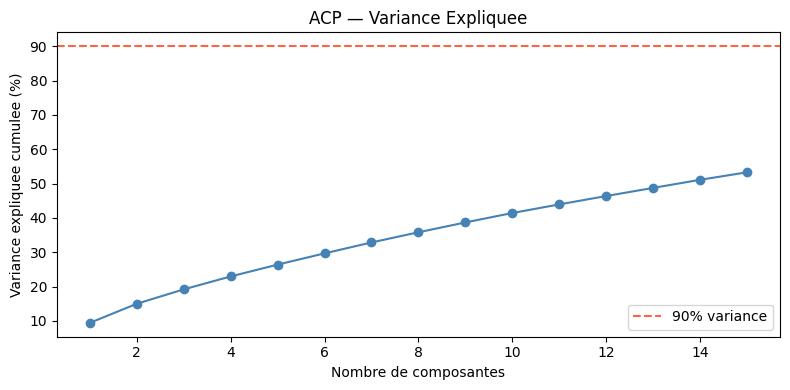

ACP : 15 composantes = 53.3% variance


['../models/pca.pkl']

In [14]:
n_components = min(15, X_train_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# Courbe de variance expliquee
explained = np.cumsum(pca.explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_components+1), explained, marker='o', color='steelblue')
ax.axhline(y=90, color='tomato', linestyle='--', label='90% variance')
ax.set_xlabel('Nombre de composantes')
ax.set_ylabel('Variance expliquee cumulee (%)')
ax.set_title('ACP — Variance Expliquee')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/pca_variance.png')
plt.show()

print(f'ACP : {n_components} composantes = {explained[-1]:.1f}% variance')
joblib.dump(pca, '../models/pca.pkl')

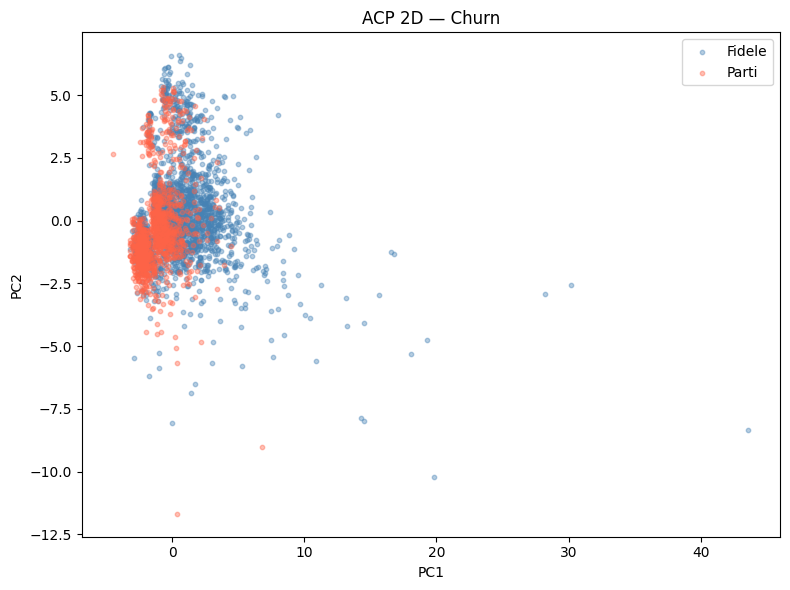

In [15]:
# Visualisation 2D
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0,'steelblue','Fidele'), (1,'tomato','Parti')]:
    mask = y_train == label
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=color, alpha=0.4, s=10, label=name)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('ACP 2D — Churn')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/pca_2d.png')
plt.show()

## Étape 4 — Clustering K-Means

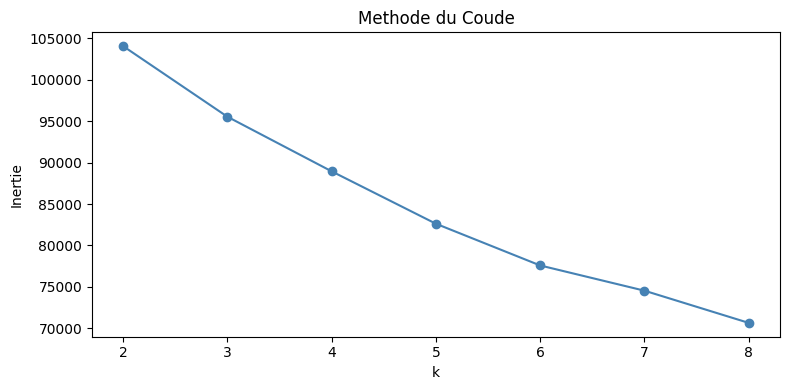

In [16]:
# Methode du coude
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue')
ax.set_xlabel('k'); ax.set_ylabel('Inertie')
ax.set_title('Methode du Coude')
plt.tight_layout()
plt.savefig('../reports/elbow.png')
plt.show()

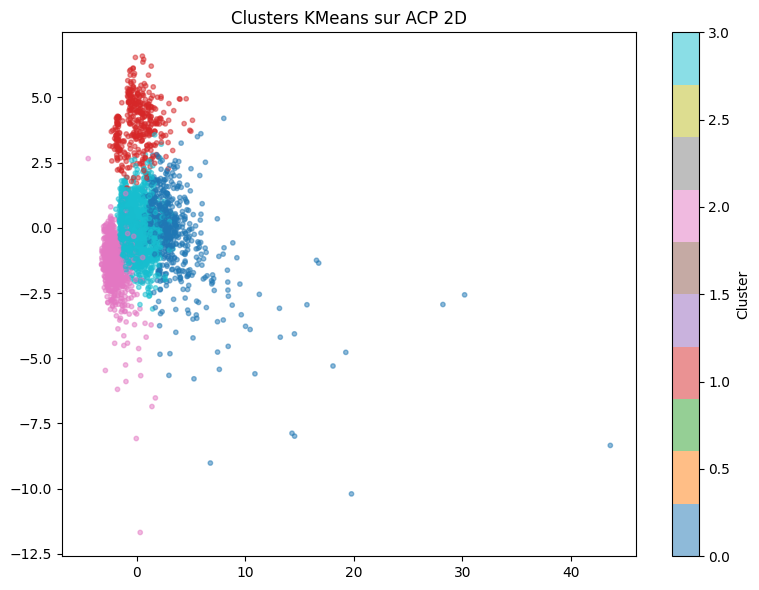


Taux de churn par cluster :
Cluster
0    0.054
1    0.351
2    0.554
3    0.293
Name: Churn, dtype: float64


In [17]:
# Entrainement KMeans avec k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
train_labels = km.fit_predict(X_train_pca)
joblib.dump(km, '../models/kmeans.pkl')

# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train_pca[:,0], X_train_pca[:,1],
                     c=train_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title('Clusters KMeans sur ACP 2D')
plt.tight_layout()
plt.savefig('../reports/clusters_pca.png')
plt.show()

# Profil des clusters
X_train_copy = X_train.copy()
X_train_copy['Cluster'] = train_labels
X_train_copy['Churn']   = y_train.values
print('\nTaux de churn par cluster :')
print(X_train_copy.groupby('Cluster')['Churn'].mean().round(3))

## Étape 5 — Classification : prédiction du Churn

In [18]:
# ── Regression Logistique ────────────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()
print(f'Regression Logistique — AUC CV : {cv_lr:.4f}')
joblib.dump(lr, '../models/logistic_regression.pkl')

Regression Logistique — AUC CV : 0.9601


['../models/logistic_regression.pkl']

In [19]:
# ── Random Forest ────────────────────────────────────────────────
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
cw = dict(zip(classes, weights))

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight=cw, random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

cv_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()
print(f'Random Forest — AUC CV : {cv_rf:.4f}')
joblib.dump(rf, '../models/random_forest.pkl')

Random Forest — AUC CV : 0.9658


['../models/random_forest.pkl']


=== Regression Logistique ===
              precision    recall  f1-score   support

      Fidele       0.95      0.90      0.93       584
       Parti       0.82      0.91      0.86       291

    accuracy                           0.91       875
   macro avg       0.89      0.91      0.90       875
weighted avg       0.91      0.91      0.91       875

AUC-ROC : 0.9611


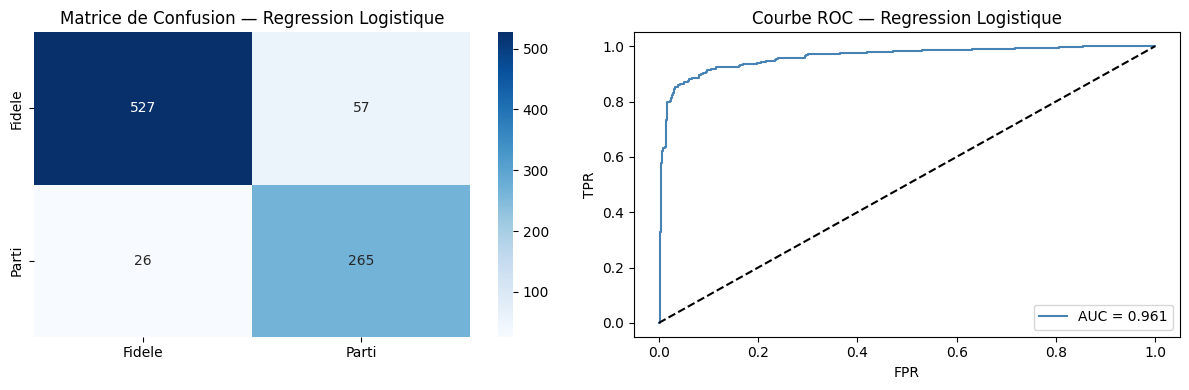


=== Random Forest ===
              precision    recall  f1-score   support

      Fidele       0.93      0.95      0.94       584
       Parti       0.90      0.85      0.87       291

    accuracy                           0.92       875
   macro avg       0.91      0.90      0.91       875
weighted avg       0.92      0.92      0.92       875

AUC-ROC : 0.9689


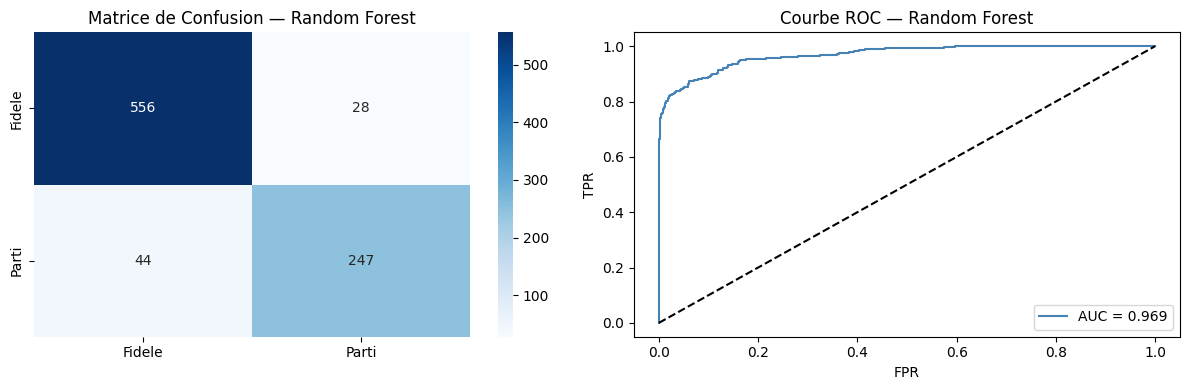

In [20]:
# ── Evaluation des deux modeles ──────────────────────────────────
def evaluate_model(model, X_test, y_test, name, save_path=None):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Fidele', 'Parti']))
    print(f'AUC-ROC : {auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Fidele', 'Parti'], yticklabels=['Fidele', 'Parti'])
    axes[0].set_title(f'Matrice de Confusion — {name}')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title(f'Courbe ROC — {name}')
    axes[1].legend()
    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()
    return auc

auc_lr = evaluate_model(lr, X_test_scaled, y_test, 'Regression Logistique', '../reports/eval_lr.png')
auc_rf = evaluate_model(rf, X_test_scaled, y_test, 'Random Forest', '../reports/eval_rf.png')

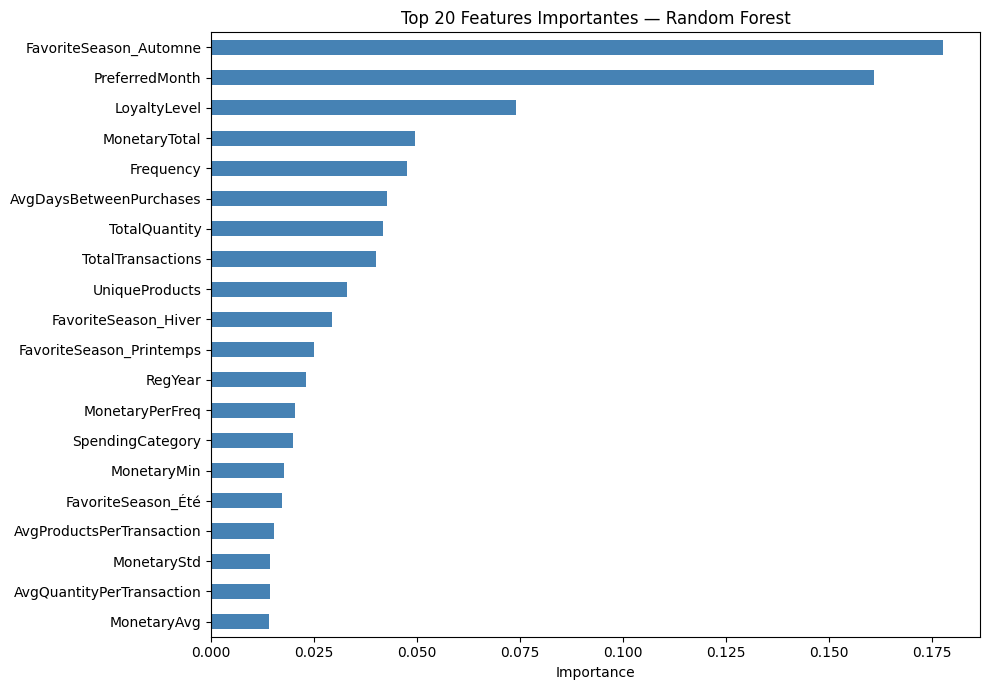

In [21]:
# ── Feature Importance (Random Forest) ──────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_train_scaled.columns)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features Importantes — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png')
plt.show()

In [22]:
# ── Comparaison des modeles ──────────────────────────────────────
print('\n=== COMPARAISON FINALE ===')
print(f'Regression Logistique AUC : {auc_lr:.4f}')
print(f'Random Forest        AUC  : {auc_rf:.4f}')
meilleur = 'Random Forest' if auc_rf > auc_lr else 'Regression Logistique'
print(f'Meilleur modele : {meilleur}')


=== COMPARAISON FINALE ===
Regression Logistique AUC : 0.9611
Random Forest        AUC  : 0.9689
Meilleur modele : Random Forest


## Étape 6 — Régression : prédiction du montant (MonetaryTotal)

Ridge Regression — RMSE: 0.4740 | R2: 0.7417


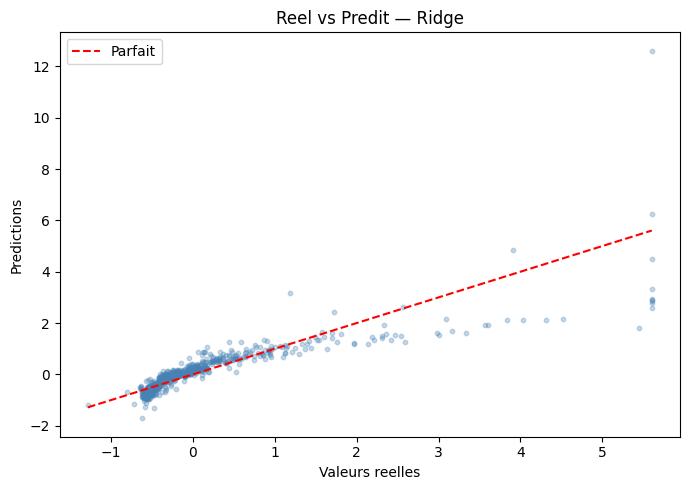

In [23]:
# Utiliser MonetaryTotal comme target de regression
# (elle est dans X_train_scaled car on ne l'a pas mise dans LEAK_COLS)
if 'MonetaryTotal' in X_train_scaled.columns:
    y_train_reg = X_train_scaled['MonetaryTotal']
    y_test_reg  = X_test_scaled['MonetaryTotal']
    X_train_reg = X_train_scaled.drop(columns=['MonetaryTotal'])
    X_test_reg  = X_test_scaled.drop(columns=['MonetaryTotal'])

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_reg, y_train_reg)
    y_pred_reg = ridge.predict(X_test_reg)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2   = r2_score(y_test_reg, y_pred_reg)
    print(f'Ridge Regression — RMSE: {rmse:.4f} | R2: {r2:.4f}')

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(y_test_reg, y_pred_reg, alpha=0.3, s=10, color='steelblue')
    ax.plot([y_test_reg.min(), y_test_reg.max()],
            [y_test_reg.min(), y_test_reg.max()], 'r--', label='Parfait')
    ax.set_xlabel('Valeurs reelles'); ax.set_ylabel('Predictions')
    ax.set_title('Reel vs Predit — Ridge')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../reports/eval_regression.png')
    plt.show()
    joblib.dump(ridge, '../models/ridge_regression.pkl')
else:
    print('MonetaryTotal non presente dans X_train_scaled')

## Étape 7 — Résumé final

In [24]:
import glob
print('=' * 50)
print('MODELES SAUVEGARDES')
print('=' * 50)
for f in sorted(glob.glob('../models/*.pkl')):
    print(f'  {f}')

print()
print('=' * 50)
print('RAPPORTS GENERES')
print('=' * 50)
for f in sorted(glob.glob('../reports/*.png')):
    print(f'  {f}')

print()
print('=' * 50)
print('RESULTATS CLASSIFICATION CHURN')
print('=' * 50)
print(f'  Logistic Regression AUC : {auc_lr:.4f}')
print(f'  Random Forest       AUC : {auc_rf:.4f}')
print()
print('Accuracy attendue : 0.80 - 0.88 (valeurs reelles, sans leakage)')

MODELES SAUVEGARDES
  ../models\imputer.pkl
  ../models\kmeans.pkl
  ../models\logistic_regression.pkl
  ../models\pca.pkl
  ../models\random_forest.pkl
  ../models\ridge_regression.pkl
  ../models\scaler.pkl

RAPPORTS GENERES
  ../reports\churn_distribution.png
  ../reports\clusters_pca.png
  ../reports\correlation_heatmap.png
  ../reports\elbow.png
  ../reports\eval_lr.png
  ../reports\eval_regression.png
  ../reports\eval_rf.png
  ../reports\feature_importance.png
  ../reports\pca_2d.png
  ../reports\pca_variance.png

RESULTATS CLASSIFICATION CHURN
  Logistic Regression AUC : 0.9611
  Random Forest       AUC : 0.9689

Accuracy attendue : 0.80 - 0.88 (valeurs reelles, sans leakage)
